## 1. Objective
This notebook establishes baseline model performance before. correcting the class imbalance. Logistic regression, decision tree, and random forest models will be trained using the original imbalance training data and evaluated on the validation set.
F1 is the primary evaluation metric, while AUC-ROC is used to mesure the models' ability to rank churned customers above retained customers across classification thresholds. The test set will remain untouched until final evaluation.

## 2. Load processed train and validation sets

In [1]:
from pathlib import Path
import pandas as pd

project_root = (
    Path.cwd().parent
    if Path.cwd().name == 'notebooks'
    else Path.cwd()
)
processed_dir = project_root / 'data' / 'processed'

In [2]:
X_train = pd.read_csv(processed_dir/ 'X_train.csv')
X_val = pd.read_csv(processed_dir/ 'X_val.csv')

y_train = pd.read_csv(processed_dir/ 'y_train.csv')['Exited']
y_val = pd.read_csv(processed_dir/ 'y_val.csv')['Exited']

## 3. Verify shapes, columns, and target proportions

In [3]:
# Verify the imported data
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')

X_train shape: (6000, 11)
X_val shape: (2000, 11)
y_train shape: (6000,)
y_val shape: (2000,)


In [4]:
# Check the columns of the imported data
X_train.columns.tolist()

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Geography_Germany',
 'Geography_Spain',
 'Gender_Male']

In [5]:
# Integrity check

assert X_train.columns.equals(X_val.columns)
assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)

forbidden_columns = {
    'RowNumber',
    'CustomerId',
    'Surname',
    'Geography',
    'Gender'
}

assert forbidden_columns.isdisjoint(X_train.columns)

print('Training and validation data loaded successfully.')

Training and validation data loaded successfully.


In [6]:
# Check that the original imbalance remains

print('Training target proportions:')
print(y_train.value_counts(normalize=True).round(4))

print('\nValidation target proportions:')
print(y_val.value_counts(normalize=True).round(4))

Training target proportions:
Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

Validation target proportions:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


## 4. Dummy classifier Baseline

A dummy classifier provides a minimun performance reference. Using the `most_frequent` strategy, it predicts the majority class for every customer without learning relationships between the features and the churn. 

Because the target is imbalance, this model may have relatively high accuracy while producing an F1 score of zero for the churn class.

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [11]:
# Train the dummy model using the training data
dummy_model = DummyClassifier(
    strategy='most_frequent',
    random_state=42
)

dummy_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.8,0.2]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](11,)","['CreditScore','Age','Tenure',...,'Geography_Germany','Geography_Spain', 'Gender_Male']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,11
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [13]:
# Validation predictions
dummy_predictions = dummy_model.predict(X_val)
dummy_probabilities = dummy_model.predict_proba(X_val)[:, 1]

In [15]:
# Dummy metrics
dummy_results = {
    'Model': 'Dummy Classifier',
    'Accuracy': accuracy_score(y_val, dummy_predictions),
    'Precision': precision_score(
        y_val,
        dummy_predictions,
        zero_division=0
    ),
    'Recall': recall_score(
        y_val,
        dummy_predictions,
        zero_division=0
    ),
    'F1': f1_score(
        y_val,
        dummy_predictions,
        zero_division=0
    ),
    'AUC-ROC': roc_auc_score(
        y_val,
        dummy_probabilities
    )
}

pd.DataFrame([dummy_results]).round(4)

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Dummy Classifier,0.7965,0.0,0.0,0.0,0.5


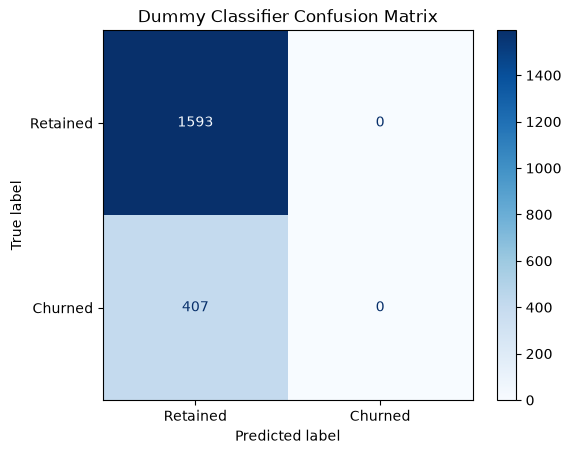

In [18]:
# Confusion matrix
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(
    y_val,
    dummy_predictions,
    display_labels=['Retained', 'Churned'],
    cmap='Blues'
)

plt.title('Dummy Classifier Confusion Matrix')
plt.show()

### Dummy-classifier findings

The dummy classifier achieved approximately 79.7% accuracy because it predicted the majority class for every customer. However, it did not identify any churned customers, resulting in precision, recall, and F1 scores of zero.

Its AUC-ROC score of 0.50 indicates no ability to distinguish churned customers from retained customers. This demonstrates why accuracy alone is misleading for this imbalanced classification problem. A useful trained model must achieve an F1 score above zero and an AUC-ROC above 0.50.

## 5. Logistic regression

## 6. Decision tree

## 7. Random forest

## 8. Validation evaluation 
- F1, 
- AUC-ROC, 
- Precision, 
- Recall, 
- Confusion matrix

## 9. Baseline conclusions